In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml /mbti_1.csv")

df.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    8675 non-null   object
 1   posts   8675 non-null   object
dtypes: object(2)
memory usage: 135.7+ KB


In [ ]:
df.describe()

,type,posts
count,8675,8675
unique,16,8675
top,INFP,'It has been too long since I have been on per...
freq,1832,1


In [ ]:
df.shape

(8675, 2)

In [ ]:
df.columns

Index(['type', 'posts'], dtype='object')

In [ ]:
df['type'].unique()

array(['INFJ', 'ENTP', 'INTP', 'INTJ', 'ENTJ', 'ENFJ', 'INFP', 'ENFP',
       'ISFP', 'ISTP', 'ISFJ', 'ISTJ', 'ESTP', 'ESFP', 'ESTJ', 'ESFJ'],
      dtype=object)

In [ ]:
df['type'].value_counts()

,count
type,
INFP,1832
INFJ,1470
INTP,1304
INTJ,1091
ENTP,685
ENFP,675
ISTP,337
ISFP,271
ENTJ,231


In [ ]:
df.isnull().sum()

,0
type,0
posts,0


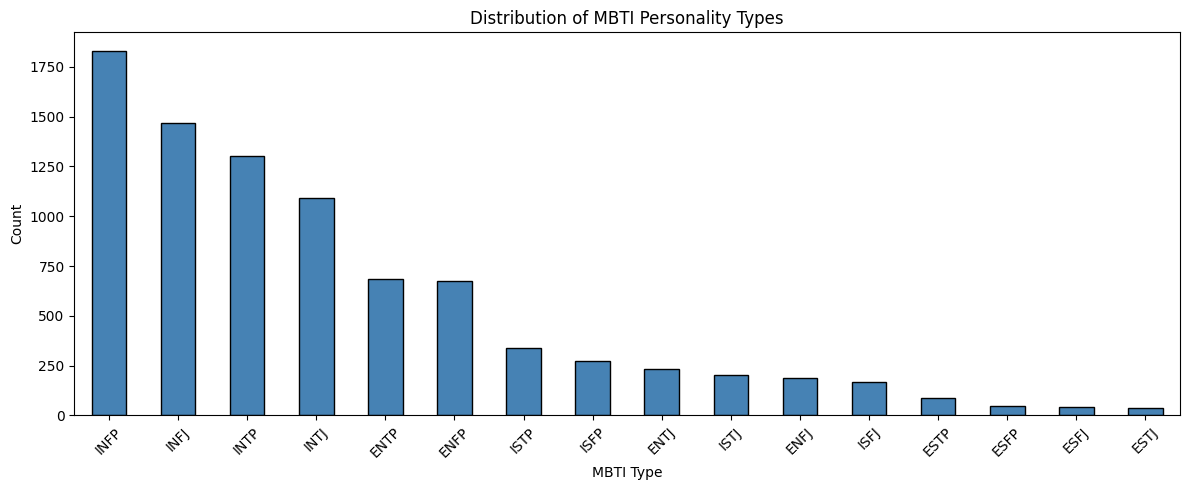

In [ ]:
plt.figure(figsize=(12,5))
df['type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of MBTI Personality Types')
plt.xlabel('MBTI Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#text processing
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    mbti_types = ['INFJ','INFP','INTJ','INTP','ISFJ','ISFP','ISTJ','ISTP',
                  'ENFJ','ENFP','ENTJ','ENTP','ESFJ','ESFP','ESTJ','ESTP']
    for t in mbti_types:
        text = re.sub(t, '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    return text

df['cleaned_posts'] = df['posts'].apply(clean_text)
df[['type','cleaned_posts']].head()

,type,cleaned_posts
0,INFJ,and moments sportscenter not top ten plays...
1,ENTP,im finding the lack of me in these posts very ...
2,INTP,good one course to which i say i know tha...
3,INTJ,dear i enjoyed our conversation the other d...
4,ENTJ,youre firedthats another silly misconception t...


In [ ]:
#feature extraction TF-IDF
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['cleaned_posts']).toarray()

le = LabelEncoder()
y_encoded = le.fit_transform(df['type'])

print('Feature matrix shape:', X_tfidf.shape)
print('Classes:', le.classes_)

Feature matrix shape: (8675, 3000)
Classes: ['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']


In [ ]:
X = X_tfidf
print(X.shape)

(8675, 3000)


In [ ]:
y = y_encoded
print(y.shape)

(8675,)


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(6940, 3000) (1735, 3000)


In [ ]:
print(X_train)

[[0.         0.         0.06309158 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.04506689 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.07195202 0.         ... 0.         0.         0.        ]]


In [ ]:
rf_classifer = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=5, oob_score=True, random_state=42)
rf_classifer.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [ ]:
y_pred = rf_classifer.predict(X_test)
print(y_pred)

[9 9 9 ... 9 8 9]


In [ ]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[  0   0   0   0   0   0   0   0   3  38   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   4 121   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   2  38   0   4   0   0   0   0]
 [  0   0   0   0   0   0   0   0   7 122   0   6   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   7   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   8   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   7   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  15   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  19 265   0   4   0   0   0   0]
 [  0   0   0   0   0   0   0   0   3 364   0   3   0   0   0   0]
 [  0   0   0   0   0   0   0   0  10 174   0   9   0   0   0   0]
 [  0   0   0   0   0   0   0   0   8 263   1  21   0   0   0   0]
 [  0   0   0   0   0   0   0   0   2  43   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  53   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   4  39   

In [ ]:
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.23285302593659943


In [ ]:
rf_classifer.oob_score_

0.22997118155619597

In [ ]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        41
        ENFP       0.00      0.00      0.00       125
        ENTJ       0.00      0.00      0.00        44
        ENTP       0.00      0.00      0.00       135
        ESFJ       0.00      0.00      0.00         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       0.00      0.00      0.00        15
        INFJ       0.29      0.07      0.11       288
        INFP       0.22      0.98      0.37       370
        INTJ       0.00      0.00      0.00       193
        INTP       0.41      0.07      0.12       293
        ISFJ       0.00      0.00      0.00        45
        ISFP       0.00      0.00      0.00        53
        ISTJ       0.00      0.00      0.00        44
        ISTP       0.00      0.00      0.00        67

    accuracy                           0.23      1735
   

In [ ]:
# GridSearchCV — Random Forest (80:20)
grid_search_rf2 = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1), param_grid=Params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search_rf2.fit(X_train, y_train)

Fitting 4 folds for each of 108 candidates, totalling 432 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)